<a href="https://colab.research.google.com/github/ChJazhiel/TEC_CCM_2026/blob/main/2D_Feature_Selection_Semana8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Selección de Variables para Predicción de Abandono en un dataset de Comercio Electrónico (E-commerce)

**Objetivo:** Comparar distintos métodos de selección de variables (filtro, embebidos, wrapper e importancia)
y evaluar su impacto en un modelo final de Random Forest.

**Dataset:** ecommerce_customer_churn_dataset.csv

**Estructura del notebook:**
1. Setup y carga de datos
2. Análisis Exploratorio (EDA)
3. Modelo baseline
4. Métodos de filtro: F-test/ANOVA, Chi²
5. Métodos embebidos: Lasso, Ridge
6. Métodos wrapper: Forward, Backward, RFE
7. Permutation Importance
8. Selección con Árbol de Decisión y Random Forest (PARTE PRÁCTICA)
9. Comparativa final y conclusiones

In [1]:
# ============================================================
# SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2,
    RFE, SequentialFeatureSelector
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
#Visualizar el dataset
df = pd.read_csv("ecommerce_customer_churn_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (50000, 25)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [3]:
#Información General (Tipos de variables)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [4]:
#Estadística Sumarizada (Transpuesta pues tenemos un total de 24 variables)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


In [5]:
# Distribución de la variable objetivo
df["Churned"].value_counts(normalize=True)*100

,proportion
Churned,
0,71.1
1,28.9


Tenemos 28.9% de Clientes que abandonaron el negocio. La finalidad es entonces encontrar la razón de esto.

## 2. Análisis Exploratorio (EDA)

Objetivos:
- Detectar nulos, duplicados y outliers
- Analizar distribuciones y correlaciones
- Identificar variables con poder discriminante sobre `Churned`

In [6]:
#Nulos y duplicados
print("Duplicados:", df.duplicated().sum())
print("\nNulos por columna:")
nulos = df.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0])

Duplicados: 0

Nulos por columna:
Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Product_Reviews_Written          3500
Discount_Usage_Rate              3500
Session_Duration_Avg             3399
Pages_Per_Session                3000
Days_Since_Last_Purchase         3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
dtype: int64


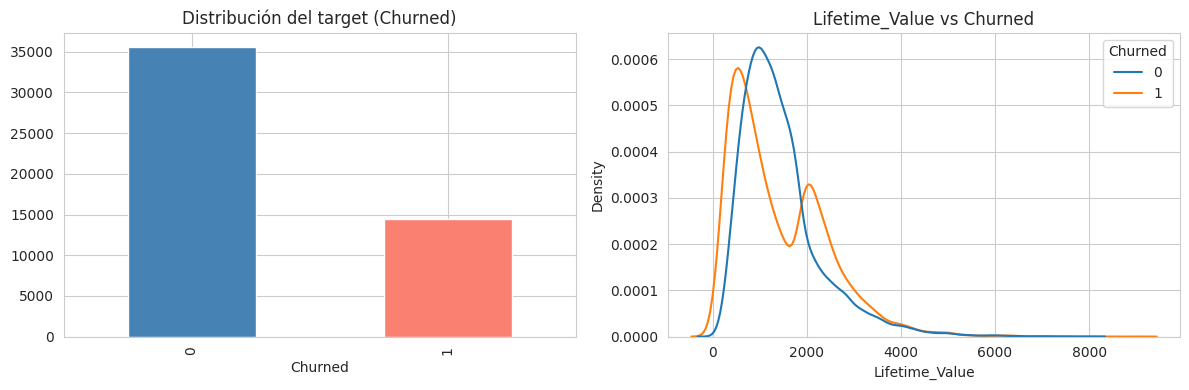

In [7]:
#Distribución de la variable objetivo y las variables numéricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Churned"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Distribución del target (Churned)")

sns.kdeplot(data=df, x="Lifetime_Value", hue="Churned", ax=axes[1], common_norm=False)
axes[1].set_title("Lifetime_Value vs Churned")
plt.tight_layout()
plt.show()

### Actividad 1. Cambia la variable numérica por `Total_Purchases`y `Average_Order_Value`y observa su distribución con la variable objetivo.

Copia todo el código anterior en la siguiente celda y
sustituye `x`en la gráfica de seaborn anterior por las variables mencionadas.

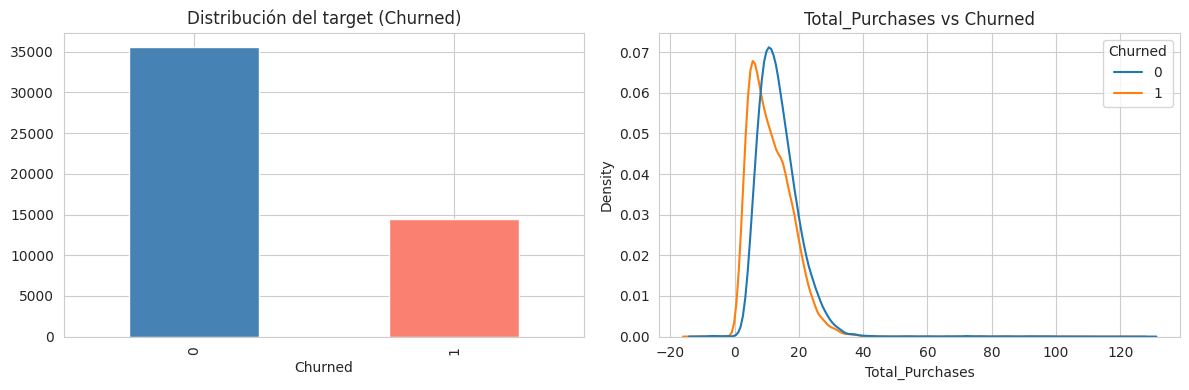

In [8]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Churned"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Distribución del target (Churned)")

sns.kdeplot(data=df, x="Total_Purchases", hue="Churned", ax=axes[1], common_norm=False)
axes[1].set_title("Total_Purchases vs Churned")
plt.tight_layout()
plt.show()

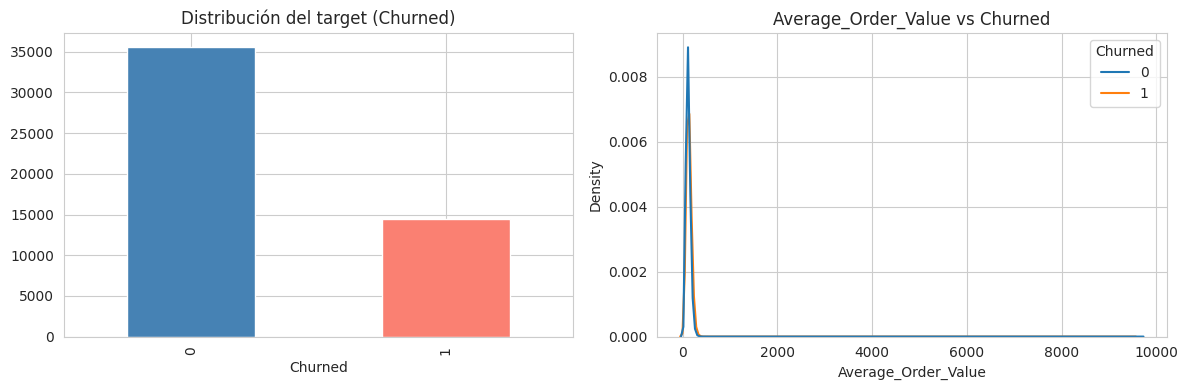

In [9]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Churned"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Distribución del target (Churned)")

sns.kdeplot(data=df, x="Average_Order_Value", hue="Churned", ax=axes[1], common_norm=False)
axes[1].set_title("Average_Order_Value vs Churned")
plt.tight_layout()
plt.show()

In [10]:
#Correlación con la variable objetivo
num_df = df.select_dtypes(include=np.number)
corr_target = num_df.corr()["Churned"].sort_values(ascending=False)
print(corr_target)

Churned                          1.000000
Customer_Service_Calls           0.291103
Cart_Abandonment_Rate            0.277963
Days_Since_Last_Purchase         0.153360
Returns_Rate                     0.054189
Average_Order_Value              0.042288
Payment_Method_Diversity         0.004524
Membership_Years                -0.000623
Lifetime_Value                  -0.010684
Discount_Usage_Rate             -0.077121
Age                             -0.102849
Credit_Balance                  -0.156921
Total_Purchases                 -0.160029
Product_Reviews_Written         -0.181225
Social_Media_Engagement_Score   -0.191792
Wishlist_Items                  -0.197708
Login_Frequency                 -0.204379
Email_Open_Rate                 -0.222213
Mobile_App_Usage                -0.222876
Session_Duration_Avg            -0.228010
Pages_Per_Session               -0.231799
Name: Churned, dtype: float64


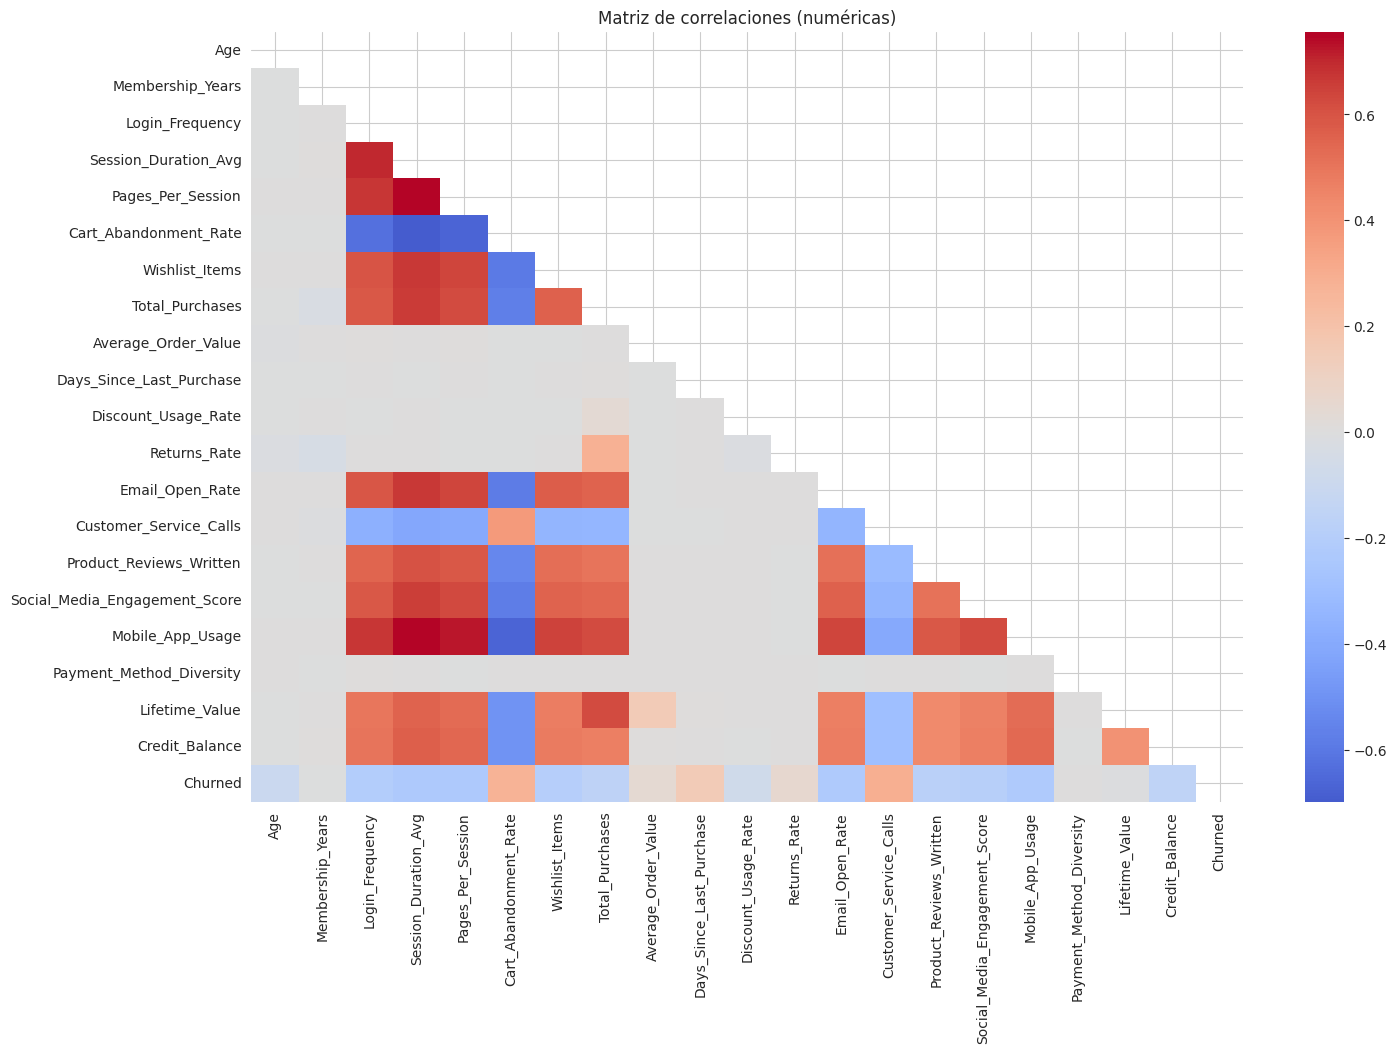

In [11]:
#Visualización de la correlación de Pearson
mask = np.triu(np.ones_like(corr_target, dtype=bool))

plt.figure(figsize=(16, 10))
sns.heatmap(num_df.corr(), cmap="coolwarm", mask=mask,  center=0, annot=False)
plt.title("Matriz de correlaciones (numéricas)")
plt.show()

In [12]:
#Variables categóricas versus el abandono
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categóricas:", cat_cols)

for col in ["Gender", "Country", "Signup_Quarter"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(pd.crosstab(df[col], df["Churned"], normalize="index"))

Categóricas: ['Gender', 'Country', 'City', 'Signup_Quarter']

--- Gender ---
Churned         0         1
Gender                     
Female   0.710264  0.289736
Male     0.712699  0.287301
Other    0.687300  0.312700

--- Country ---
Churned           0         1
Country                      
Australia  0.701059  0.298941
Canada     0.706459  0.293541
France     0.727137  0.272863
Germany    0.711675  0.288325
India      0.709852  0.290148
Japan      0.721743  0.278257
UK         0.712105  0.287895
USA        0.709158  0.290842

--- Signup_Quarter ---
Churned                0         1
Signup_Quarter                    
Q1              0.706818  0.293182
Q2              0.703298  0.296702
Q3              0.715719  0.284281
Q4              0.718158  0.281842


In [13]:
#Preprocesamiento base
# Separar X / y
X = df.drop(columns=["Churned"])
y = df["Churned"].astype(int) #Convertimos a numérica booleana

# Identificar tipos
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

print(f"Numéricas ({len(num_features)}):", num_features)
print(f"Categóricas ({len(cat_features)}):", cat_features)

Numéricas (20): ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']
Categóricas (4): ['Gender', 'Country', 'City', 'Signup_Quarter']


##3. Pipeline de preprocesamiento

In [14]:
# Pipelines de preprocesamiento

#Para variables numéricas, imputamos con la mediana y normalizamos (Z score)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Para variables categóricas, imputamos con la observación más frecuente y realizamos OneHotEncoding
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
]) if False else Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", __import__("sklearn.preprocessing", fromlist=["OneHotEncoder"]).OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

#Definimos un preprocesamiento que aplique a las columnas (variables del dataset)
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Split
#Dividimos el dataset en 80% entrenamiento, 20% testeo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (40000, 24) Test: (10000, 24)


## 4. Evaluar modelo Base

Se evalúa un random forest para predecir el abandono de clientes

In [15]:
def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    """Entrena y evalúa un pipeline. Devuelve métricas."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1":       f1_score(y_test, y_pred),
        "ROC_AUC":  roc_auc_score(y_test, y_proba),
        "N_Features": pipeline.named_steps["pre"].transform(X_train).shape[1]
    }
    return metrics, pipeline

# Baseline con todas las variables
baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

results = []
m, _ = evaluate_model("Baseline (todas)", baseline_pipe,
                       X_train, y_train, X_test, y_test)
results.append(m)
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75


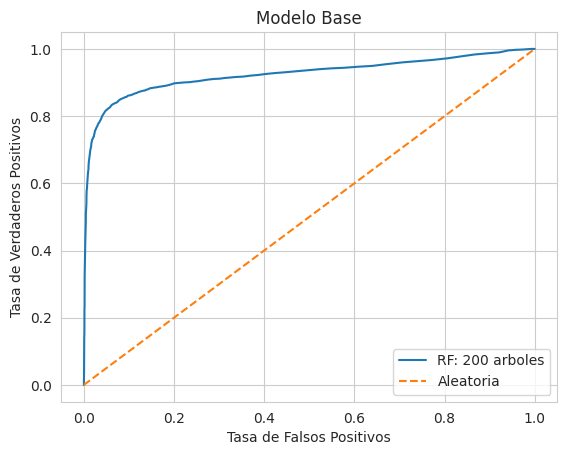

In [16]:
# Gráfica de la Curva ROC
from sklearn.metrics import roc_curve
y_proba = baseline_pipe.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label="RF: 200 arboles")
plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Modelo Base")
plt.legend()
plt.show()

## 4. Métodos de Filtro

- **F-test / ANOVA (`f_classif`)**: compara medias de cada feature entre clases.
  Útil para features numéricas. Devuelve un estadístico F y un p-value.
- **Chi-cuadrado (`chi2`)**: mide dependencia entre features no negativas y la clase.

### 4.1 F-Test y ANOVA

In [17]:
# Transformamos primero todo a numérico
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test)

# Recuperar nombres de columnas tras OneHotEncoder
feature_names = preprocessor.get_feature_names_out()
print("N features tras preprocesamiento:", len(feature_names))

# -------- F-test ----------
selector_f = SelectKBest(score_func=f_classif, k=15)
X_train_f = selector_f.fit_transform(X_train_pre, y_train)
X_test_f  = selector_f.transform(X_test_pre)

f_scores = pd.DataFrame({
    "feature": feature_names,
    "F": selector_f.scores_,
    "p_value": selector_f.pvalues_
}).sort_values("F", ascending=False)

print("Top 15 F-test:")
print(f_scores.head(15))

N features tras preprocesamiento: 75
Top 15 F-test:
                               feature            F        p_value
13         num__Customer_Service_Calls  3600.934473   0.000000e+00
5           num__Cart_Abandonment_Rate  3326.657291   0.000000e+00
4               num__Pages_Per_Session  2093.294764   0.000000e+00
3            num__Session_Duration_Avg  1991.504421   0.000000e+00
12                num__Email_Open_Rate  1929.623962   0.000000e+00
16               num__Mobile_App_Usage  1845.268275   0.000000e+00
2                 num__Login_Frequency  1725.656070   0.000000e+00
6                  num__Wishlist_Items  1482.222937  1.922103e-318
15  num__Social_Media_Engagement_Score  1286.930615  2.003518e-277
14        num__Product_Reviews_Written  1224.964700  2.281632e-264
7                 num__Total_Purchases  1008.764843  1.178163e-218
19                 num__Credit_Balance   886.072965  1.331726e-192
9        num__Days_Since_Last_Purchase   866.783606  1.690051e-188
0         

### 4.2 Evaluación del Random Forest con las 15 variables más relevantes (numéricas)

In [18]:
# Evaluamos con Random Forest usando las top-15
pipe_f = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])
pipe_f.fit(X_train_f, y_train)
y_pred = pipe_f.predict(X_test_f)
y_proba = pipe_f.predict_proba(X_test_f)[:, 1]

results.append({
    "Modelo": "F-test (k=15)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_f.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15


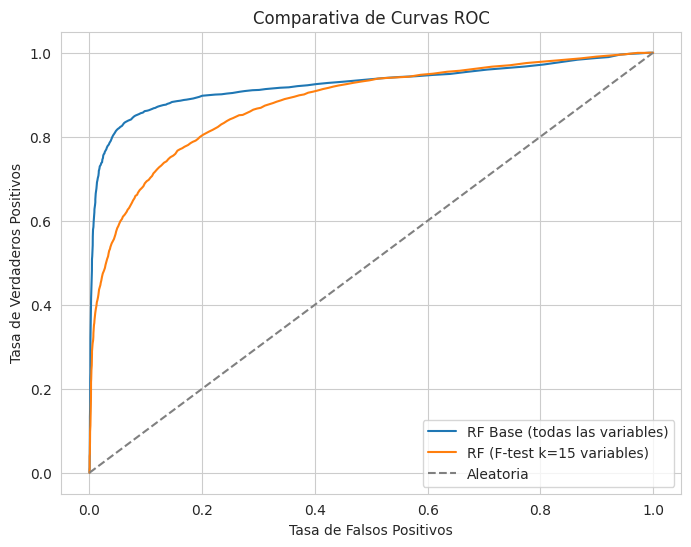

In [19]:
#Graficar el modelo base y el de menos variables
plt.figure(figsize=(8, 6))

# Curva ROC para el Modelo Base
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr_base, tpr_base, label="RF Base (todas las variables)")

# Curva ROC para el modelo con F-test (k=15)
y_proba_f = pipe_f.predict_proba(X_test_f)[:, 1] # Corrected: use X_test_f
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
plt.plot(fpr_f, tpr_f, label="RF (F-test k=15 variables)")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC")
plt.legend()
plt.grid(True)
plt.show()

###4.3 $\chi^2$. Prueba de Chi-cuadrada

In [20]:
# Chi² necesita valores NO negativos
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler() # Crea UNA instancia del escalador
X_train_pos = scaler_minmax.fit_transform(X_train_pre) # Ajusta y transforma con los datos de entrenamiento
X_test_pos  = scaler_minmax.transform(X_test_pre)  # Usa la MISMA instancia ajustada para transformar los datos de prueba

selector_chi = SelectKBest(score_func=chi2, k=15)
X_train_chi = selector_chi.fit_transform(X_train_pos, y_train)
X_test_chi  = selector_chi.transform(X_test_pos)

chi_scores = pd.DataFrame({
    "feature": feature_names,
    "Chi2": selector_chi.scores_,
    "p_value": selector_chi.pvalues_
}).sort_values("Chi2", ascending=False)

print("Top 15 Chi²:")
print(chi_scores.head(15))

Top 15 Chi²:
                               feature        Chi2       p_value
13         num__Customer_Service_Calls  197.772674  6.395840e-45
2                 num__Login_Frequency  197.209453  8.488142e-45
12                num__Email_Open_Rate  185.732746  2.715407e-42
15  num__Social_Media_Engagement_Score  160.286148  9.797805e-37
4               num__Pages_Per_Session  151.384314  8.637549e-35
16               num__Mobile_App_Usage  117.965108  1.764652e-27
6                  num__Wishlist_Items  111.803524  3.945340e-26
3            num__Session_Duration_Avg  105.644959  8.820363e-25
14        num__Product_Reviews_Written  103.707947  2.344490e-24
5           num__Cart_Abandonment_Rate   99.338676  2.128113e-23
9        num__Days_Since_Last_Purchase   85.002134  2.980432e-20
19                 num__Credit_Balance   82.389784  1.117298e-19
10            num__Discount_Usage_Rate   19.186560  1.185451e-05
7                 num__Total_Purchases   13.306695  2.644601e-04
68          

### 4.4 Evaluación del modelo con prueba de chi cuadrada

In [21]:
rf_chi_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_chi_model.fit(X_train_chi, y_train)
y_pred_chi = rf_chi_model.predict(X_test_chi)
y_proba_chi_for_metrics = rf_chi_model.predict_proba(X_test_chi)[:, 1]

results.append({
    "Modelo": "Chi² (k=15)",
    "Accuracy": accuracy_score(y_test, y_pred_chi),
    "F1":       f1_score(y_test, y_pred_chi),
    "ROC_AUC":  roc_auc_score(y_test, y_proba_chi_for_metrics),
    "N_Features": X_train_chi.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15


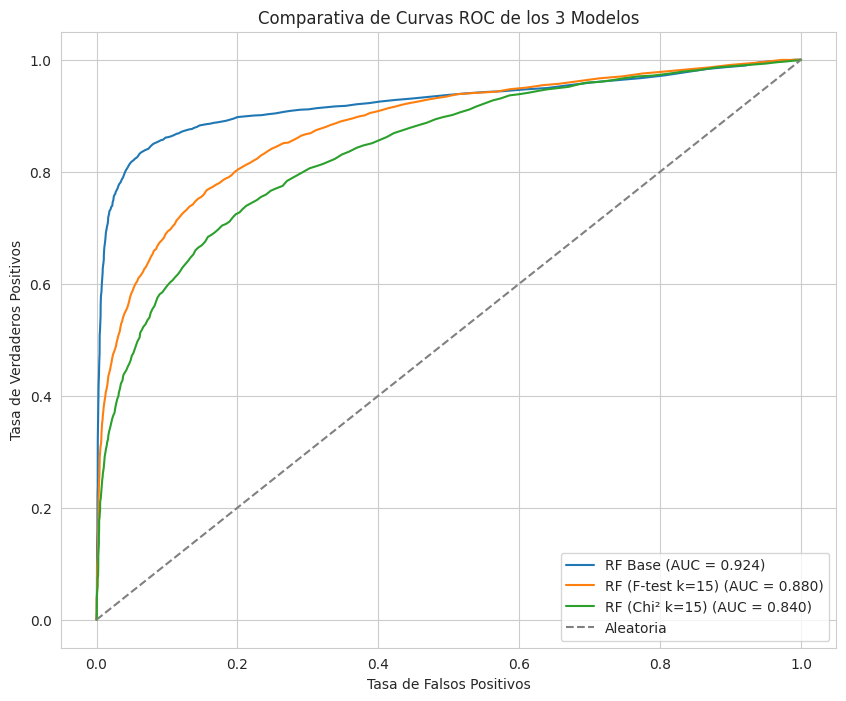

In [22]:
plt.figure(figsize=(10, 8))

# Curva ROC para el Modelo Base
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr_base, tpr_base, label=f"RF Base (AUC = {roc_auc_score(y_test, y_proba_base):.3f})")

# Curva ROC para el modelo con F-test (k=15)
y_proba_f = pipe_f.predict_proba(X_test_f)[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
plt.plot(fpr_f, tpr_f, label=f"RF (F-test k=15) (AUC = {roc_auc_score(y_test, y_proba_f):.3f})")

# Curva ROC para el modelo con Chi² (k=15)
y_proba_chi = rf_chi_model.predict_proba(X_test_chi)[:, 1]
fpr_chi, tpr_chi, _ = roc_curve(y_test, y_proba_chi)
plt.plot(fpr_chi, tpr_chi, label=f"RF (Chi² k=15) (AUC = {roc_auc_score(y_test, y_proba_chi):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC de los 3 Modelos")
plt.legend()
plt.grid(True)
plt.show()

## 5. Métodos Embebidos: Lasso y Ridge

- **Lasso (L1)**: lleva coeficientes a cero ⇒ selección automática.
- **Ridge (L2)**: penaliza coeficientes pero no los elimina ⇒ útil para ver importancia relativa.

In [23]:
# Lasso con validación cruzada sobre las features preprocesadas
lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000, n_jobs=-1)
lasso.fit(X_train_pre, y_train)

lasso_coef = pd.DataFrame({
    "feature": feature_names,
    "coef": lasso.coef_
})
lasso_selected = lasso_coef[lasso_coef["coef"].abs() > 1e-4].sort_values("coef", key=np.abs, ascending=False)

print(f"Features seleccionadas por Lasso: {len(lasso_selected)}")
print(lasso_selected.head(20))

Features seleccionadas por Lasso: 21
                          feature      coef
18            num__Lifetime_Value  0.119887
13    num__Customer_Service_Calls  0.098640
5      num__Cart_Abandonment_Rate  0.091288
9   num__Days_Since_Last_Purchase  0.066323
0                        num__Age -0.045351
7            num__Total_Purchases -0.033645
10       num__Discount_Usage_Rate -0.032701
11              num__Returns_Rate  0.029899
12           num__Email_Open_Rate -0.026684
4          num__Pages_Per_Session -0.018399
74         cat__Signup_Quarter_Q4  0.011780
25            cat__Country_France -0.007732
14   num__Product_Reviews_Written -0.005826
6             num__Wishlist_Items -0.004297
16          num__Mobile_App_Usage -0.004014
2            num__Login_Frequency -0.002969
73         cat__Signup_Quarter_Q3 -0.002616
1           num__Membership_Years  0.002013
17  num__Payment_Method_Diversity  0.001496
8        num__Average_Order_Value  0.001383


###. 5.1 Evaluación del modelo con Lasso Regression

In [24]:
# Máscara de selección
mask_lasso = lasso_coef["coef"].abs().values > 1e-4
X_train_lasso = X_train_pre[:, mask_lasso]
X_test_lasso  = X_test_pre[:, mask_lasso]

rf_lasso_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_lasso_model.fit(X_train_lasso, y_train)
y_pred_lasso = rf_lasso_model.predict(X_test_lasso)
y_proba_lasso_for_metrics = rf_lasso_model.predict_proba(X_test_lasso)[:, 1]

results.append({
    "Modelo": "Lasso",
    "Accuracy": accuracy_score(y_test, y_pred_lasso),
    "F1":       f1_score(y_test, y_pred_lasso),
    "ROC_AUC":  roc_auc_score(y_test, y_proba_lasso_for_metrics),
    "N_Features": X_train_lasso.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21


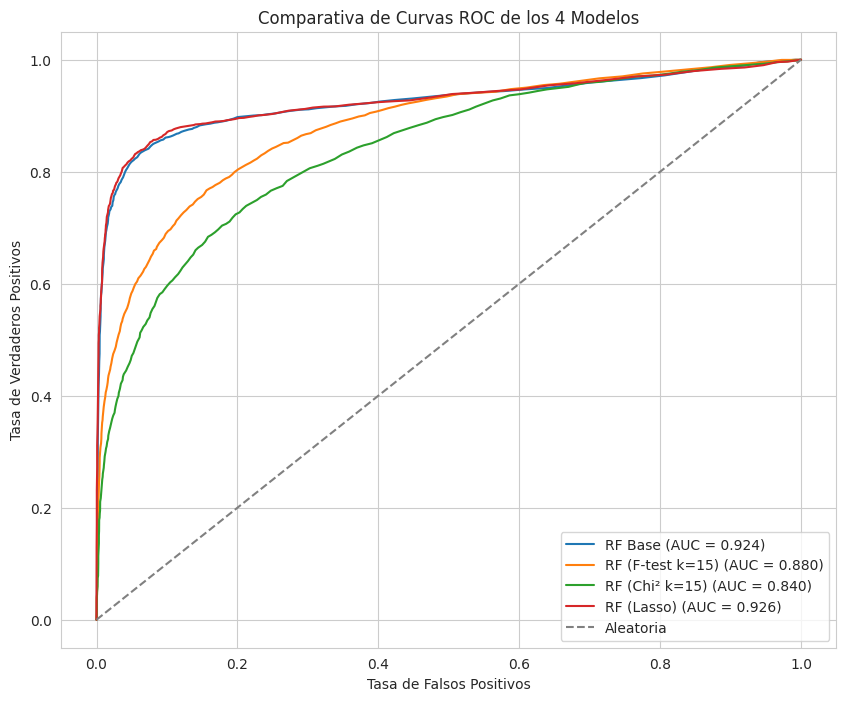

In [25]:
plt.figure(figsize=(10, 8))

# Curva ROC para el Modelo Base
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr_base, tpr_base, label=f"RF Base (AUC = {roc_auc_score(y_test, y_proba_base):.3f})")

# Curva ROC para el modelo con F-test (k=15)
y_proba_f = pipe_f.predict_proba(X_test_f)[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
plt.plot(fpr_f, tpr_f, label=f"RF (F-test k=15) (AUC = {roc_auc_score(y_test, y_proba_f):.3f})")

# Curva ROC para el modelo con Chi² (k=15)
y_proba_chi = rf_chi_model.predict_proba(X_test_chi)[:, 1]
fpr_chi, tpr_chi, _ = roc_curve(y_test, y_proba_chi)
plt.plot(fpr_chi, tpr_chi, label=f"RF (Chi² k=15) (AUC = {roc_auc_score(y_test, y_proba_chi):.3f})")

# Curva ROC para el modelo Lasso
y_proba_lasso = rf_lasso_model.predict_proba(X_test_lasso)[:, 1]
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_proba_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f"RF (Lasso) (AUC = {roc_auc_score(y_test, y_proba_lasso):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC de los 4 Modelos")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
#Regresion Ridge con diferentes valores de alpha (2 evaluaciones)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5)
ridge.fit(X_train_pre, y_train)

ridge_coef = pd.DataFrame({
    "feature": feature_names,
    "coef": ridge.coef_
}).sort_values("coef", key=np.abs, ascending=False)

# Seleccionamos top-k por magnitud (Ridge no elimina)
TOP_K = 15
top_ridge_features = ridge_coef.head(TOP_K)["feature"].values
mask_ridge = np.isin(feature_names, top_ridge_features)

X_train_ridge = X_train_pre[:, mask_ridge]
X_test_ridge  = X_test_pre[:, mask_ridge]

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_ridge, y_train)
y_pred = rf.predict(X_test_ridge)
y_proba = rf.predict_proba(X_test_ridge)[:, 1]

results.append({
    "Modelo": f"Ridge (top {TOP_K})",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_ridge.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15


###5.2 Evaluación del modelo con Ridge Regression

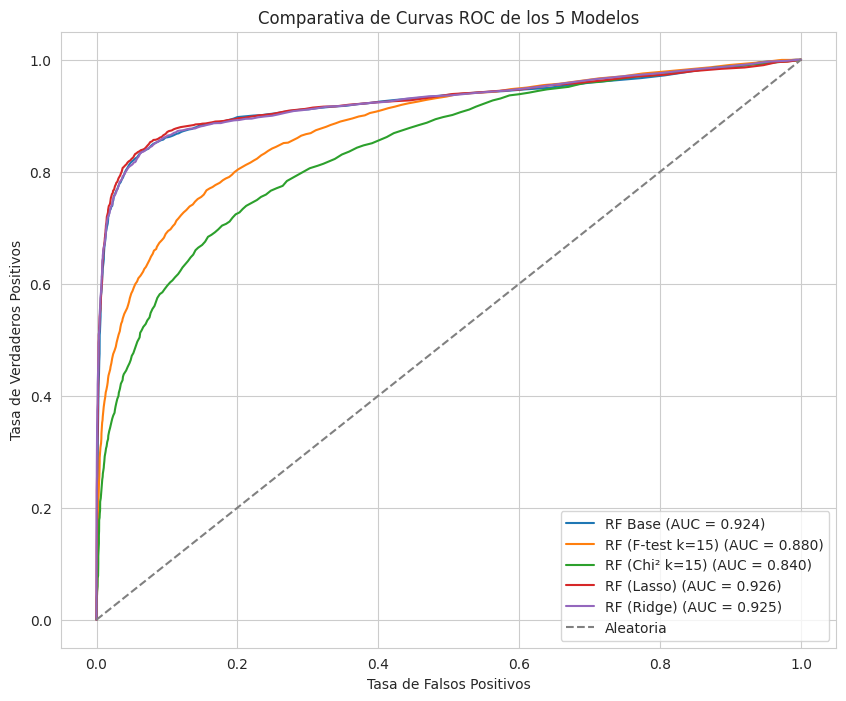

In [27]:
plt.figure(figsize=(10, 8))

# Curva ROC para el Modelo Base
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr_base, tpr_base, label=f"RF Base (AUC = {roc_auc_score(y_test, y_proba_base):.3f})")

# Curva ROC para el modelo con F-test (k=15)
y_proba_f = pipe_f.predict_proba(X_test_f)[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
plt.plot(fpr_f, tpr_f, label=f"RF (F-test k=15) (AUC = {roc_auc_score(y_test, y_proba_f):.3f})")

# Curva ROC para el modelo con Chi² (k=15)
y_proba_chi = rf_chi_model.predict_proba(X_test_chi)[:, 1]
fpr_chi, tpr_chi, _ = roc_curve(y_test, y_proba_chi)
plt.plot(fpr_chi, tpr_chi, label=f"RF (Chi² k=15) (AUC = {roc_auc_score(y_test, y_proba_chi):.3f})")

# Curva ROC para el modelo Lasso
y_proba_lasso = rf_lasso_model.predict_proba(X_test_lasso)[:, 1]
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_proba_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f"RF (Lasso) (AUC = {roc_auc_score(y_test, y_proba_lasso):.3f})")

# Curva ROC para el modelo Ridge
y_proba_ridge = rf.predict_proba(X_test_ridge)[:, 1]
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_proba_ridge)
plt.plot(fpr_ridge, tpr_ridge, label=f"RF (Ridge) (AUC = {roc_auc_score(y_test, y_proba_ridge):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC de los 5 Modelos")
plt.legend()
plt.grid(True)
plt.show()

## 6. Métodos Wrapper

- **Forward Selection**: parte del conjunto vacío y añade variables de a una.
- **Backward Selection**: parte del conjunto completo y elimina variables de a una.
- **RFE**: elimina recursivamente las menos importantes según un estimador.

⚠️ Son costosos computacionalmente. Usaremos `SequentialFeatureSelector` con CV ligera.

In [28]:
from sklearn.linear_model import LogisticRegression

# Para acelerar, usamos un subconjunto de features (top 30 por F-test)
top30_idx = np.argsort(selector_f.scores_)[-30:]
X_train_top30 = X_train_pre[:, top30_idx]
X_test_top30  = X_test_pre[:, top30_idx]
top30_names   = feature_names[top30_idx]

base_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# -------- Forward ----------
sfs_forward = SequentialFeatureSelector(
    base_lr, n_features_to_select=10, direction="forward", cv=3, n_jobs=-1
)
sfs_forward.fit(X_train_top30, y_train)
mask_fwd = sfs_forward.get_support()
print("Forward seleccionó:", list(top30_names[mask_fwd]))

Forward seleccionó: ['num__Payment_Method_Diversity', 'cat__City_Toulouse', 'num__Returns_Rate', 'num__Days_Since_Last_Purchase', 'num__Product_Reviews_Written', 'num__Wishlist_Items', 'num__Mobile_App_Usage', 'num__Email_Open_Rate', 'num__Pages_Per_Session', 'num__Cart_Abandonment_Rate']


In [29]:
# -------- Backward ----------
sfs_backward = SequentialFeatureSelector(
    base_lr, n_features_to_select=10, direction="backward", cv=3, n_jobs=-1
)
sfs_backward.fit(X_train_top30, y_train)
mask_bwd = sfs_backward.get_support()
print("Backward seleccionó:", list(top30_names[mask_bwd]))

Backward seleccionó: ['num__Lifetime_Value', 'num__Returns_Rate', 'num__Age', 'num__Days_Since_Last_Purchase', 'num__Total_Purchases', 'num__Wishlist_Items', 'num__Email_Open_Rate', 'num__Pages_Per_Session', 'num__Cart_Abandonment_Rate', 'num__Customer_Service_Calls']


In [30]:
# Evaluar ambos
for nombre, mask in [("Forward (10)", mask_fwd), ("Backward (10)", mask_bwd)]:
    Xtr = X_train_top30[:, mask]
    Xte = X_test_top30[:, mask]
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(Xtr, y_train)
    y_pred = rf.predict(Xte)
    y_proba = rf.predict_proba(Xte)[:, 1]
    results.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1":       f1_score(y_test, y_pred),
        "ROC_AUC":  roc_auc_score(y_test, y_proba),
        "N_Features": Xtr.shape[1]
    })
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15
5,Forward (10),0.8025,0.551442,0.726781,10
6,Backward (10),0.8826,0.774404,0.912386,10


###5.3 Recursive Feature Elimination

In [31]:
rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    n_features_to_select=15, step=2
)
rfe.fit(X_train_pre, y_train)
mask_rfe = rfe.support_

print("RFE seleccionó:")
for f, r in zip(feature_names[mask_rfe], rfe.ranking_[mask_rfe]):
    print(" -", f, "rank:", r)

X_train_rfe = X_train_pre[:, mask_rfe]
X_test_rfe  = X_test_pre[:, mask_rfe]

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_rfe, y_train)
y_pred = rf.predict(X_test_rfe)
y_proba = rf.predict_proba(X_test_rfe)[:, 1]

results.append({
    "Modelo": "RFE (15)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_rfe.shape[1]
})
pd.DataFrame(results)

RFE seleccionó:
 - num__Age rank: 1
 - num__Login_Frequency rank: 1
 - num__Session_Duration_Avg rank: 1
 - num__Pages_Per_Session rank: 1
 - num__Cart_Abandonment_Rate rank: 1
 - num__Total_Purchases rank: 1
 - num__Average_Order_Value rank: 1
 - num__Days_Since_Last_Purchase rank: 1
 - num__Discount_Usage_Rate rank: 1
 - num__Returns_Rate rank: 1
 - num__Email_Open_Rate rank: 1
 - num__Customer_Service_Calls rank: 1
 - num__Mobile_App_Usage rank: 1
 - num__Lifetime_Value rank: 1
 - num__Credit_Balance rank: 1


,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15
5,Forward (10),0.8025,0.551442,0.726781,10
6,Backward (10),0.8826,0.774404,0.912386,10
7,RFE (15),0.9165,0.844420,0.927518,15


###5.4 Permutation Importance (NO EJECUTAR EN CLASE)

In [32]:
# Entrenamos RF sobre TODAS las features y medimos importancia por permutación
rf_full = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_full.fit(X_train_pre, y_train)

perm = permutation_importance(
    rf_full, X_test_pre, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 20 Permutation Importance:")
print(perm_df.head(20))

Top 20 Permutation Importance:
                          feature  importance_mean  importance_std
13    num__Customer_Service_Calls         0.129132        0.002399
18            num__Lifetime_Value         0.099450        0.003150
0                        num__Age         0.055515        0.000909
10       num__Discount_Usage_Rate         0.033211        0.001443
5      num__Cart_Abandonment_Rate         0.026500        0.001022
9   num__Days_Since_Last_Purchase         0.022091        0.000929
12           num__Email_Open_Rate         0.004705        0.000685
11              num__Returns_Rate         0.003423        0.000321
3       num__Session_Duration_Avg         0.001813        0.000750
4          num__Pages_Per_Session         0.000998        0.000695
8        num__Average_Order_Value         0.000903        0.000787
16          num__Mobile_App_Usage         0.000633        0.000595
6             num__Wishlist_Items         0.000605        0.000344
2            num__Login_Frequen

In [33]:
# Seleccionamos top-15 por permutation importance
top_perm = perm_df.head(15)["feature"].values
mask_perm = np.isin(feature_names, top_perm)
X_train_perm = X_train_pre[:, mask_perm]
X_test_perm  = X_test_pre[:, mask_perm]

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_perm, y_train)
y_pred = rf.predict(X_test_perm)
y_proba = rf.predict_proba(X_test_perm)[:, 1]

results.append({
    "Modelo": "Permutation Importance (15)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_perm.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15
5,Forward (10),0.8025,0.551442,0.726781,10
6,Backward (10),0.8826,0.774404,0.912386,10
7,RFE (15),0.9165,0.844420,0.927518,15
8,Permutation Importance (15),0.9176,0.846555,0.926784,15


## 6. Selección de características basado en modelos

###6.1 Arbol de decisión con baja profundidad

Top 15 features según Árbol de Decisión:
                          feature  importance
18            num__Lifetime_Value    0.383819
5      num__Cart_Abandonment_Rate    0.198863
13    num__Customer_Service_Calls    0.109162
10       num__Discount_Usage_Rate    0.102415
7            num__Total_Purchases    0.070169
0                        num__Age    0.061841
9   num__Days_Since_Last_Purchase    0.043354
12           num__Email_Open_Rate    0.024220
3       num__Session_Duration_Avg    0.004720
11              num__Returns_Rate    0.001436
1           num__Membership_Years    0.000000
8        num__Average_Order_Value    0.000000
6             num__Wishlist_Items    0.000000
4          num__Pages_Per_Session    0.000000
2            num__Login_Frequency    0.000000


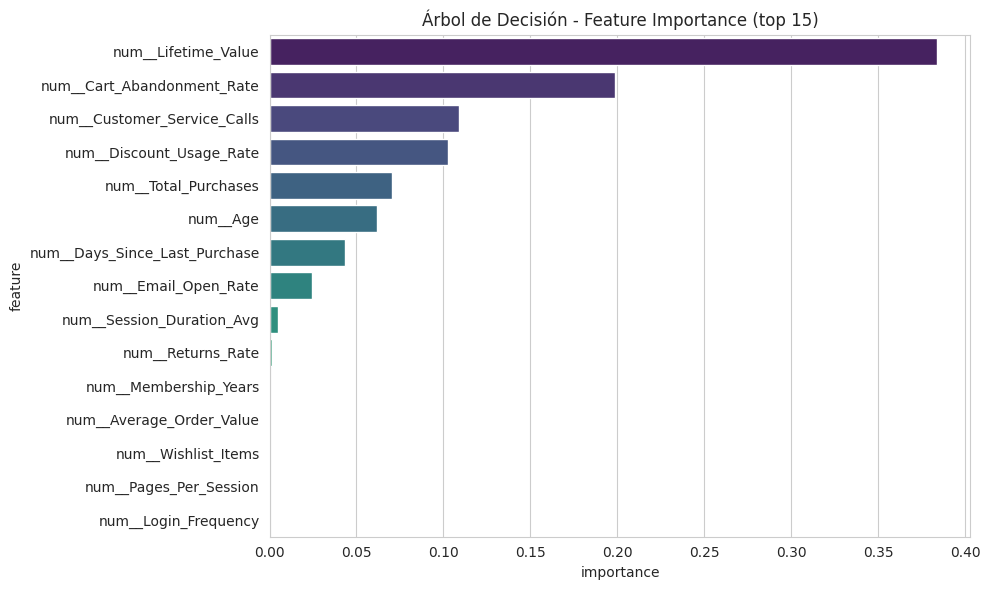

In [34]:
dt_selector = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt_selector.fit(X_train_pre, y_train)

dt_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_selector.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 features según Árbol de Decisión:")
print(dt_importance.head(15))

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=dt_importance.head(15), x="importance", y="feature", palette="viridis")
plt.title("Árbol de Decisión - Feature Importance (top 15)")
plt.tight_layout()
plt.show()

### Ejercicio: Aumenta la profundidad del árbol a 8, selecciona al menos 20 datos por hoja (`min_samples_leaf=20`) y Cambia el criterio de selección a Entropía

Top 15 features según Árbol de Decisión:
                          feature  importance
18            num__Lifetime_Value    0.245433
5      num__Cart_Abandonment_Rate    0.192043
13    num__Customer_Service_Calls    0.140148
10       num__Discount_Usage_Rate    0.130042
0                        num__Age    0.075120
7            num__Total_Purchases    0.071310
9   num__Days_Since_Last_Purchase    0.062693
12           num__Email_Open_Rate    0.039677
3       num__Session_Duration_Avg    0.014357
11              num__Returns_Rate    0.009776
4          num__Pages_Per_Session    0.005967
2            num__Login_Frequency    0.004769
16          num__Mobile_App_Usage    0.003258
6             num__Wishlist_Items    0.001213
14   num__Product_Reviews_Written    0.001099


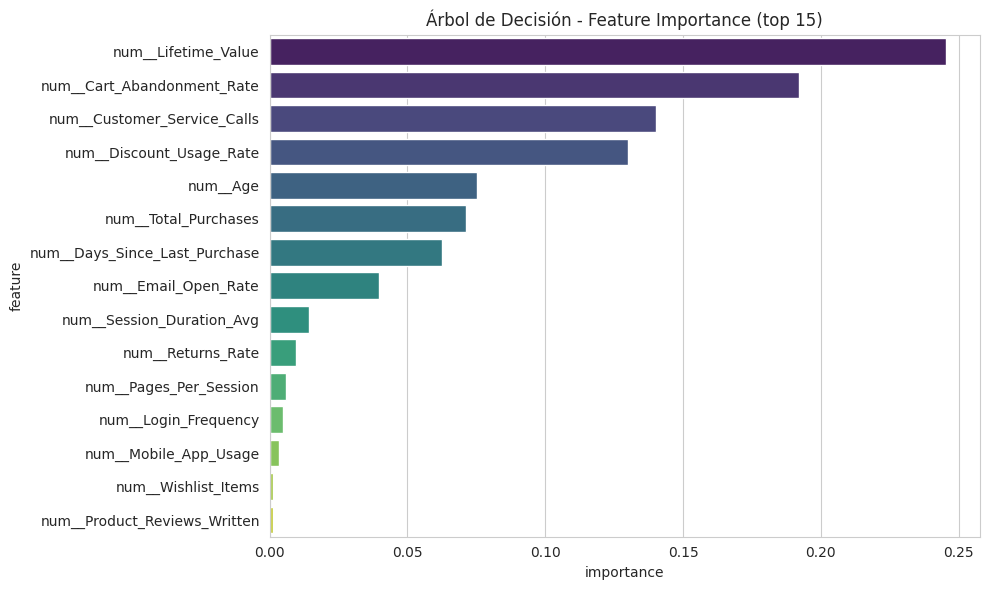

In [35]:
dt_selector = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE,min_samples_leaf=20, criterion='entropy')
dt_selector.fit(X_train_pre, y_train)

dt_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_selector.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 features según Árbol de Decisión:")
print(dt_importance.head(15))

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=dt_importance.head(15), x="importance", y="feature", palette="viridis")
plt.title("Árbol de Decisión - Feature Importance (top 15)")
plt.tight_layout()
plt.show()

In [36]:
# Seleccionamos top-15 y evaluamos
top_dt = dt_importance.head(15)["feature"].values
mask_dt = np.isin(feature_names, top_dt)

X_train_dt = X_train_pre[:, mask_dt]
X_test_dt  = X_test_pre[:, mask_dt]

rf_dt = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_dt.fit(X_train_dt, y_train)
y_pred = rf_dt.predict(X_test_dt)
y_proba = rf_dt.predict_proba(X_test_dt)[:, 1]

results.append({
    "Modelo": "Árbol de Decisión (15)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_dt.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15
5,Forward (10),0.8025,0.551442,0.726781,10
6,Backward (10),0.8826,0.774404,0.912386,10
7,RFE (15),0.9165,0.844420,0.927518,15
8,Permutation Importance (15),0.9176,0.846555,0.926784,15
9,Árbol de Decisión (15),0.9185,0.848541,0.929060,15


## Random Forest Feature Importance
Seleccionamos características de un random forest para posteriormente entrenar un random forest 😀

Top 15 features según Random Forest:
                               feature  importance
18                 num__Lifetime_Value    0.113024
13         num__Customer_Service_Calls    0.108753
5           num__Cart_Abandonment_Rate    0.087622
0                             num__Age    0.062705
10            num__Discount_Usage_Rate    0.055976
9        num__Days_Since_Last_Purchase    0.051160
8             num__Average_Order_Value    0.047826
7                 num__Total_Purchases    0.045999
12                num__Email_Open_Rate    0.042657
4               num__Pages_Per_Session    0.039642
3            num__Session_Duration_Avg    0.038570
16               num__Mobile_App_Usage    0.034506
11                   num__Returns_Rate    0.029902
2                 num__Login_Frequency    0.026925
15  num__Social_Media_Engagement_Score    0.026319


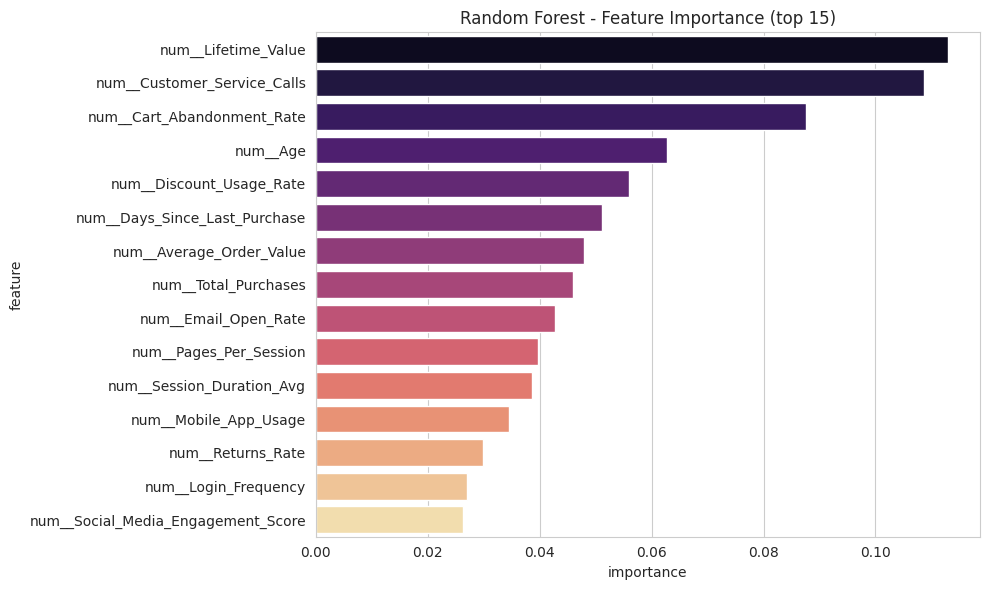

In [37]:
# ============================================================
# RETO 2: RANDOM FOREST COMO SELECTOR
# ============================================================
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_full.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 features según Random Forest:")
print(rf_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(15), x="importance", y="feature", palette="magma")
plt.title("Random Forest - Feature Importance (top 15)")
plt.tight_layout()
plt.show()

In [38]:
#Entrenar el random forest con las variables seleccionadas previamente
top_rf = rf_importance.head(15)["feature"].values
mask_rf = np.isin(feature_names, top_rf)

X_train_rf = X_train_pre[:, mask_rf]
X_test_rf  = X_test_pre[:, mask_rf]

rf_final = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_final.fit(X_train_rf, y_train)
y_pred = rf_final.predict(X_test_rf)
y_proba = rf_final.predict_proba(X_test_rf)[:, 1]

results.append({
    "Modelo": "Random Forest (15)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_rf.shape[1]
})
pd.DataFrame(results)

,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15
5,Forward (10),0.8025,0.551442,0.726781,10
6,Backward (10),0.8826,0.774404,0.912386,10
7,RFE (15),0.9165,0.844420,0.927518,15
8,Permutation Importance (15),0.9176,0.846555,0.926784,15
9,Árbol de Decisión (15),0.9185,0.848541,0.929060,15


###6.3 Comparativa de curva ROC de todos los métodos de selección de variables

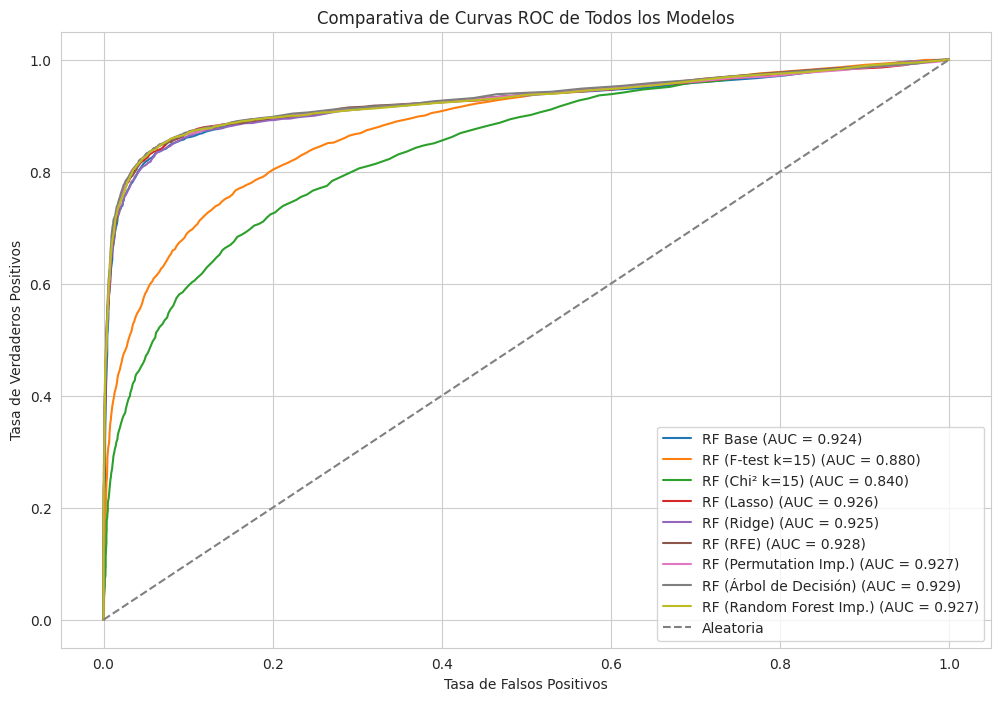

In [39]:
plt.figure(figsize=(12, 8))

# Curva ROC para el Modelo Base
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr_base, tpr_base, label=f"RF Base (AUC = {roc_auc_score(y_test, y_proba_base):.3f})")

# Curva ROC para el modelo con F-test (k=15)
y_proba_f = pipe_f.predict_proba(X_test_f)[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
plt.plot(fpr_f, tpr_f, label=f"RF (F-test k=15) (AUC = {roc_auc_score(y_test, y_proba_f):.3f})")

# Curva ROC para el modelo con Chi² (k=15)
y_proba_chi = rf_chi_model.predict_proba(X_test_chi)[:, 1]
fpr_chi, tpr_chi, _ = roc_curve(y_test, y_proba_chi)
plt.plot(fpr_chi, tpr_chi, label=f"RF (Chi² k=15) (AUC = {roc_auc_score(y_test, y_proba_chi):.3f})")

# Curva ROC para el modelo Lasso
y_proba_lasso = rf_lasso_model.predict_proba(X_test_lasso)[:, 1]
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_proba_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f"RF (Lasso) (AUC = {roc_auc_score(y_test, y_proba_lasso):.3f})")

# Re-entrenar modelo Ridge para asegurar la correcta correspondencia de features
rf_ridge_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_ridge_plot_model.fit(X_train_ridge, y_train)
y_proba_ridge = rf_ridge_plot_model.predict_proba(X_test_ridge)[:, 1]
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_proba_ridge)
plt.plot(fpr_ridge, tpr_ridge, label=f"RF (Ridge) (AUC = {roc_auc_score(y_test, y_proba_ridge):.3f})")

# Re-entrenar modelo RFE para asegurar la correcta correspondencia de features
rf_rfe_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_rfe_plot_model.fit(X_train_rfe, y_train)
y_proba_rfe = rf_rfe_plot_model.predict_proba(X_test_rfe)[:, 1]
fpr_rfe, tpr_rfe, _ = roc_curve(y_test, y_proba_rfe)
plt.plot(fpr_rfe, tpr_rfe, label=f"RF (RFE) (AUC = {roc_auc_score(y_test, y_proba_rfe):.3f})")

# Re-entrenar modelo Permutation Importance para asegurar la correcta correspondencia de features
rf_perm_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_perm_plot_model.fit(X_train_perm, y_train)
y_proba_perm = rf_perm_plot_model.predict_proba(X_test_perm)[:, 1]
fpr_perm, tpr_perm, _ = roc_curve(y_test, y_proba_perm)
plt.plot(fpr_perm, tpr_perm, label=f"RF (Permutation Imp.) (AUC = {roc_auc_score(y_test, y_proba_perm):.3f})")

# Curva ROC para el modelo Árbol de Decisión (ya tenemos rf_dt)
y_proba_dt = rf_dt.predict_proba(X_test_dt)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f"RF (Árbol de Decisión) (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})")

# Curva ROC para el modelo Random Forest (15)
y_proba_rf_final = rf_final.predict_proba(X_test_rf)[:, 1]
fpr_rf_final, tpr_rf_final, _ = roc_curve(y_test, y_proba_rf_final)
plt.plot(fpr_rf_final, tpr_rf_final, label=f"RF (Random Forest Imp.) (AUC = {roc_auc_score(y_test, y_proba_rf_final):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC de Todos los Modelos")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# ============================================================
# RETO 3: SelectFromModel con DT y RF
# ============================================================
from sklearn.feature_selection import SelectFromModel

# --- con Decision Tree ---
sfm_dt = SelectFromModel(
    DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE, min_samples_leaf=20, criterion='entropy'),
    threshold="median"
)
X_train_sfm_dt = sfm_dt.fit_transform(X_train_pre, y_train)
X_test_sfm_dt  = sfm_dt.transform(X_test_pre)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sfm_dt, y_train)
y_pred = rf.predict(X_test_sfm_dt)
y_proba = rf.predict_proba(X_test_sfm_dt)[:, 1]
results.append({
    "Modelo": "SelectFromModel DT",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_sfm_dt.shape[1]
})

# --- con Random Forest ---
sfm_rf = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=20, criterion='entropy'),
    threshold="median"
)
X_train_sfm_rf = sfm_rf.fit_transform(X_train_pre, y_train)
X_test_sfm_rf  = sfm_rf.transform(X_test_pre)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sfm_rf, y_train)
y_pred = rf.predict(X_test_sfm_rf)
y_proba = rf.predict_proba(X_test_sfm_rf)[:, 1]
results.append({
    "Modelo": "SelectFromModel RF",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1":       f1_score(y_test, y_pred),
    "ROC_AUC":  roc_auc_score(y_test, y_proba),
    "N_Features": X_train_sfm_rf.shape[1]
})
pd.DataFrame(results)


,Modelo,Accuracy,F1,ROC_AUC,N_Features
0,Baseline (todas),0.9123,0.834121,0.923926,75
1,F-test (k=15),0.8438,0.698572,0.880018,15
2,Chi² (k=15),0.8142,0.624495,0.839695,15
3,Lasso,0.9160,0.843284,0.925709,21
4,Ridge (top 15),0.9124,0.836384,0.925452,15
5,Forward (10),0.8025,0.551442,0.726781,10
6,Backward (10),0.8826,0.774404,0.912386,10
7,RFE (15),0.9165,0.844420,0.927518,15
8,Permutation Importance (15),0.9176,0.846555,0.926784,15
9,Árbol de Decisión (15),0.9185,0.848541,0.929060,15


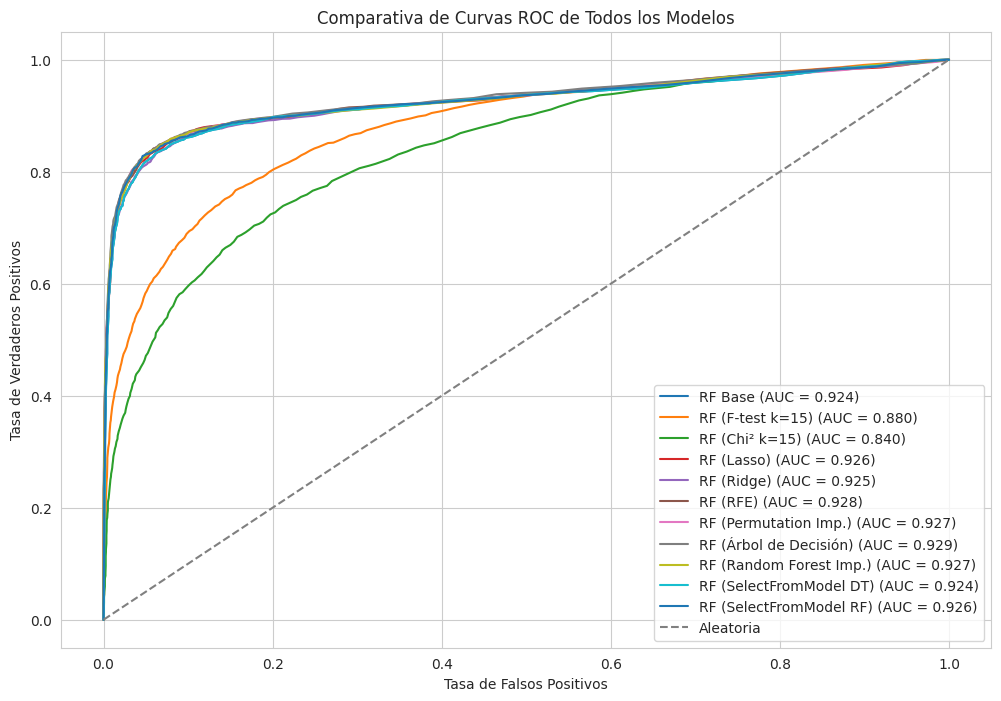

In [41]:
plt.figure(figsize=(12, 8))

# Curva ROC para el Modelo Base
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
plt.plot(fpr_base, tpr_base, label=f"RF Base (AUC = {roc_auc_score(y_test, y_proba_base):.3f})")

# Curva ROC para el modelo con F-test (k=15)
y_proba_f = pipe_f.predict_proba(X_test_f)[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_f)
plt.plot(fpr_f, tpr_f, label=f"RF (F-test k=15) (AUC = {roc_auc_score(y_test, y_proba_f):.3f})")

# Curva ROC para el modelo con Chi² (k=15)
y_proba_chi = rf_chi_model.predict_proba(X_test_chi)[:, 1]
fpr_chi, tpr_chi, _ = roc_curve(y_test, y_proba_chi)
plt.plot(fpr_chi, tpr_chi, label=f"RF (Chi² k=15) (AUC = {roc_auc_score(y_test, y_proba_chi):.3f})")

# Curva ROC para el modelo Lasso
y_proba_lasso = rf_lasso_model.predict_proba(X_test_lasso)[:, 1]
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_proba_lasso)
plt.plot(fpr_lasso, tpr_lasso, label=f"RF (Lasso) (AUC = {roc_auc_score(y_test, y_proba_lasso):.3f})")

# Re-entrenar modelo Ridge para asegurar la correcta correspondencia de features
rf_ridge_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_ridge_plot_model.fit(X_train_ridge, y_train)
y_proba_ridge = rf_ridge_plot_model.predict_proba(X_test_ridge)[:, 1]
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_proba_ridge)
plt.plot(fpr_ridge, tpr_ridge, label=f"RF (Ridge) (AUC = {roc_auc_score(y_test, y_proba_ridge):.3f})")

# Re-entrenar modelo RFE para asegurar la correcta correspondencia de features
rf_rfe_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_rfe_plot_model.fit(X_train_rfe, y_train)
y_proba_rfe = rf_rfe_plot_model.predict_proba(X_test_rfe)[:, 1]
fpr_rfe, tpr_rfe, _ = roc_curve(y_test, y_proba_rfe)
plt.plot(fpr_rfe, tpr_rfe, label=f"RF (RFE) (AUC = {roc_auc_score(y_test, y_proba_rfe):.3f})")

# Re-entrenar modelo Permutation Importance para asegurar la correcta correspondencia de features
rf_perm_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_perm_plot_model.fit(X_train_perm, y_train)
y_proba_perm = rf_perm_plot_model.predict_proba(X_test_perm)[:, 1]
fpr_perm, tpr_perm, _ = roc_curve(y_test, y_proba_perm)
plt.plot(fpr_perm, tpr_perm, label=f"RF (Permutation Imp.) (AUC = {roc_auc_score(y_test, y_proba_perm):.3f})")

# Curva ROC para el modelo Árbol de Decisión (ya tenemos rf_dt)
y_proba_dt = rf_dt.predict_proba(X_test_dt)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f"RF (Árbol de Decisión) (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})")

# Curva ROC para el modelo Random Forest (15)
y_proba_rf_final = rf_final.predict_proba(X_test_rf)[:, 1]
fpr_rf_final, tpr_rf_final, _ = roc_curve(y_test, y_proba_rf_final)
plt.plot(fpr_rf_final, tpr_rf_final, label=f"RF (Random Forest Imp.) (AUC = {roc_auc_score(y_test, y_proba_rf_final):.3f})")

# Curva ROC para SelectFromModel DT
rf_sfm_dt_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_sfm_dt_plot_model.fit(X_train_sfm_dt, y_train)
y_proba_sfm_dt = rf_sfm_dt_plot_model.predict_proba(X_test_sfm_dt)[:, 1]
fpr_sfm_dt, tpr_sfm_dt, _ = roc_curve(y_test, y_proba_sfm_dt)
plt.plot(fpr_sfm_dt, tpr_sfm_dt, label=f"RF (SelectFromModel DT) (AUC = {roc_auc_score(y_test, y_proba_sfm_dt):.3f})")

# Curva ROC para SelectFromModel RF
rf_sfm_rf_plot_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_sfm_rf_plot_model.fit(X_train_sfm_rf, y_train)
y_proba_sfm_rf = rf_sfm_rf_plot_model.predict_proba(X_test_sfm_rf)[:, 1]
fpr_sfm_rf, tpr_sfm_rf, _ = roc_curve(y_test, y_proba_sfm_rf)
plt.plot(fpr_sfm_rf, tpr_sfm_rf, label=f"RF (SelectFromModel RF) (AUC = {roc_auc_score(y_test, y_proba_sfm_rf):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatoria")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Comparativa de Curvas ROC de Todos los Modelos")
plt.legend()
plt.grid(True)
plt.show()

## 7. Comparativa final

In [42]:
# ============================================================
# COMPARATIVA FINAL
# ============================================================
res_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
res_df = res_df.reset_index(drop=True)
print(res_df.to_string(index=False))

                     Modelo  Accuracy       F1  ROC_AUC  N_Features
     Árbol de Decisión (15)    0.9185 0.848541 0.929060          15
                   RFE (15)    0.9165 0.844420 0.927518          15
Permutation Importance (15)    0.9176 0.846555 0.926784          15
         Random Forest (15)    0.9166 0.844808 0.926595          15
         SelectFromModel RF    0.9173 0.845853 0.926333          38
                      Lasso    0.9160 0.843284 0.925709          21
             Ridge (top 15)    0.9124 0.836384 0.925452          15
           Baseline (todas)    0.9123 0.834121 0.923926          75
         SelectFromModel DT    0.9123 0.834121 0.923926          75
              Backward (10)    0.8826 0.774404 0.912386          10
              F-test (k=15)    0.8438 0.698572 0.880018          15
                Chi² (k=15)    0.8142 0.624495 0.839695          15
               Forward (10)    0.8025 0.551442 0.726781          10


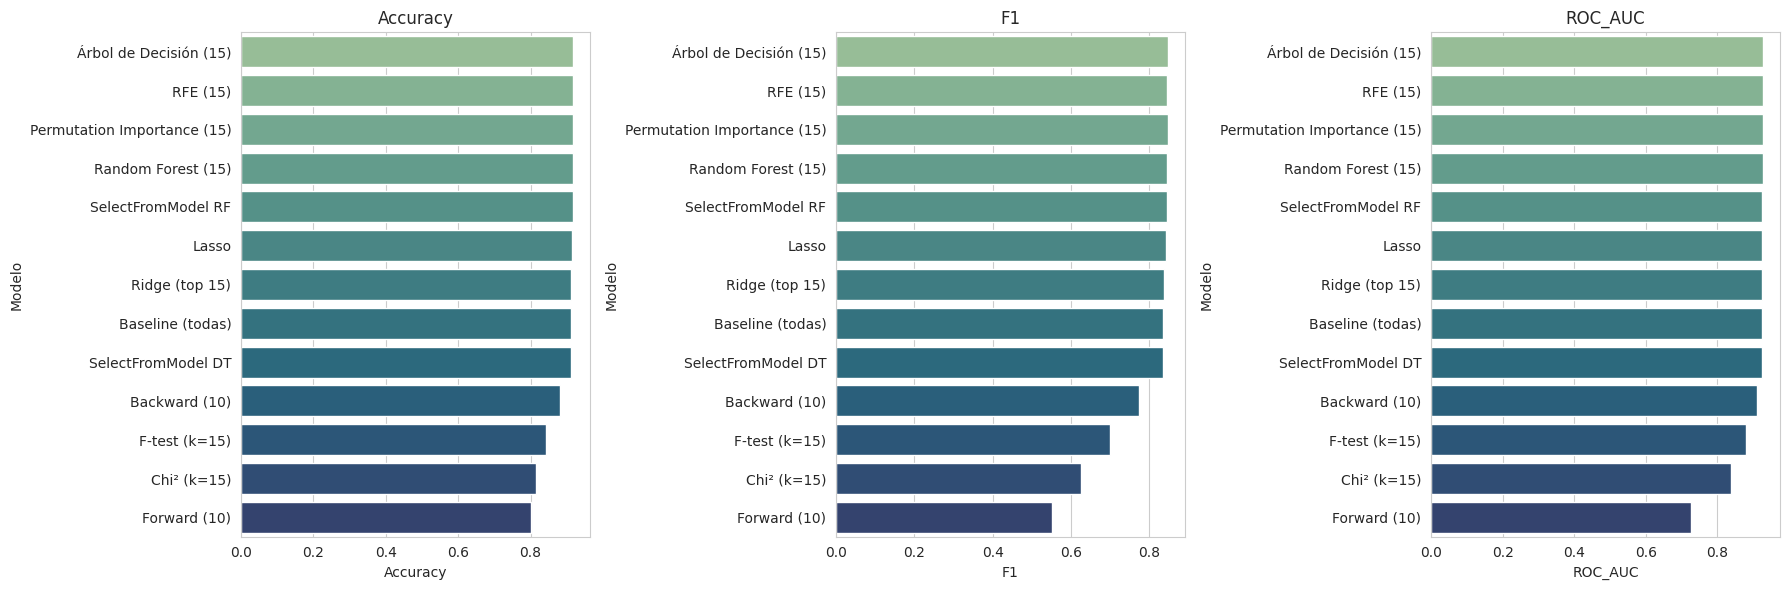

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, ["Accuracy", "F1", "ROC_AUC"]):
    sns.barplot(data=res_df, y="Modelo", x=metric, ax=ax, palette="crest")
    ax.set_title(metric)
plt.tight_layout()
plt.show()

In [44]:
best_row = res_df.iloc[0]
print("Mejor modelo según ROC_AUC:", best_row["Modelo"])
print(best_row)

Mejor modelo según ROC_AUC: Árbol de Decisión (15)
Modelo        Árbol de Decisión (15)
Accuracy                      0.9185
F1                          0.848541
ROC_AUC                      0.92906
N_Features                        15
Name: 0, dtype: object


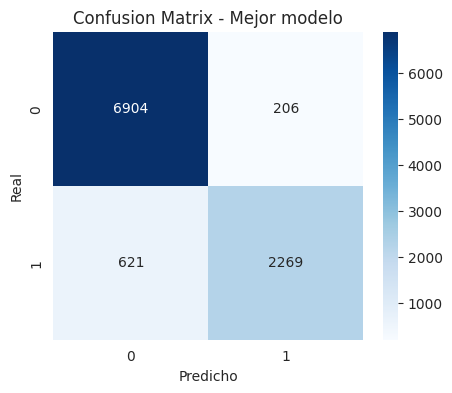

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7110
           1       0.92      0.79      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.89     10000
weighted avg       0.92      0.92      0.92     10000



In [45]:
# Elegimos el mejor pipeline y mostramos matriz de confusión
# (aquí elegimos Random Forest con top-15 del propio RF como ejemplo)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Mejor modelo")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

print(classification_report(y_test, y_pred))

## 8. Conclusiones

- **Baseline** (todas las variables) suele tener buen rendimiento pero mayor costo y riesgo de overfitting.
- **Métodos de filtro** (F-test, Chi²) son rápidos y funcionan bien cuando hay muchas features.
- **Lasso** elimina features automáticamente; **Ridge** solo las penaliza.
- **Wrapper** (Forward/Backward/RFE) dan buenos resultados pero son costosos computacionalmente.
- **Permutation Importance** es robusto y detecta las características con impacto real en el conjunto de prueba.
- **Árbol de Decisión** y **Random Forest** como selectores son muy efectivos y baratos computacionalmente, pero hay que notar lo siguiente
  - `feature_importances_` es rápido (aunque sesgado hacia variables de alta cardinalidad).
  - Combinar con **Permutation Importance** mejora la confianza en el modelo.
- El modelo final recomendado es **Decision tree sobre top-k features seleccionadas por el propio DT o por Permutation Importance**, obteniendo un ROC-AUC similar o superior al baseline con muchas menos variables.

### Recomendaciones de negocio
- Monitorear variables top: `Lifetime_Value`, `Total_Purchases`, `Days_Since_Last_Purchase`,
  `Login_Frequency`, `Cart_Abandonment_Rate`.